# Change Analysis

[Click here](https://iom-tagapp-beta.pla.sh) to access the **IOM TAGGING (BETA) PLATFORM**

In [ ]:
from iomeval.llm_eval.changes import *

from fastcore.all import *
from iomeval.readers import load_evals
from pathlib import Path

In [ ]:
p = Path().home() / 'iomeval/data/requester_by_report_id.json'
lut = p.read_json()
evls_test = L(lut.keys())

ROOT_PATH = Path.home() / 'iomeval'
DATA_PATH = ROOT_PATH / 'data'
RESULTS_PATH = DATA_PATH/ 'results'
EVALS_PATH = ROOT_PATH / 'nbs/files/test/evaluations.json'

# Contains latest backed up data before new deployment
LATEST_TAG_PATH = Path.home() / 'tagapp/backups/20260311_115159/data'

evals = load_evals(EVALS_PATH)

In [ ]:
dfs = all_deltas(evls_test, RESULTS_PATH, LATEST_TAG_PATH)

In [ ]:
who = set(lut.values())
who


{'Andres', 'Davide', 'elma', 'pip', 'rogers'}

In [ ]:
# Automaticall generate changes report cells for all reports
rpts = [k for k,v in lut.items() if v=='Davide']
for rpt in rpts: await gen_report_cells(rpt, dfs, LATEST_TAG_PATH, RESULTS_PATH)

## What we changed?

New prompts incorporating the following updates:

1. **GCM 23 downgrading**: Added an important note on GCM Objective 23 clarifying its revised scoring treatment.
2. **SRF enablers reframing**: Introduced a critical distinction between enablers as institutional capacity versus programmatic tools.
3. **Relevance score range relabelling**: Tags now use "Not Relevant", "Peripheral" (formerly "Supplementary"), "Relevant", and "Fundamental".
4. **Terminology warning on "Findings"** — Analysts must not use "finding(s)" in their own analytical language, as this term carries a specific formal meaning in IOM evaluation reports. It may only be referenced when it appears in report excerpts themselves.
5. **Excerpt-based analysis clarification**: Made explicit that only report excerpts are accessed (executive summary, introduction, summary, background, evaluation scope, conclusions, recommendations, lessons learnt), not full documents. Hedged language is required throughout (e.g., "the excerpts suggest…", "based on the sections reviewed…"). The Findings section will be handled in a later iteration.
6. **[GCM descriptions](https://raw.githubusercontent.com/franckalbinet/iomeval/refs/heads/main/nbs/files/themes/gcms_long.md) added**: Each GCM objective now includes a short description before the list of actions so as to reflect exactly the GA resolution. For instance:
```
# Objective 1
## Title: Collect and utilize accurate and disaggregated data as a basis for evidence-based policies
We commit to strengthen the global evidence base on international migration by improving and investing in the collection, analysis and dissemination of accurate , ...
To realize this commitment, we will draw from the following actions:
## Associated actions
- a. Elaborate and implement ...
- b. ...
...
```

7. **More rigorous section selection**: Sections are now selected more carefully following a curation step.

Here are links to [new](https://github.com/franckalbinet/iomeval/tree/main/nbs/files/prompts) and [previous](https://github.com/franckalbinet/iomeval/tree/main/nbs/files/prompts/legacy) versions of the prompts.

How did these changes affect tagging?

## Score changes overview

Based on **20 reports only** for now.

### GCM objectives

*Note: You might be unfamiliar with this type of visualization. It's called a [violin plot](https://en.wikipedia.org/wiki/Violin_plot). A violin plot combines a box plot with a smoothed estimate of the score distribution, making it easier to spot not just the median and spread, but also whether scores cluster around one or several values, something a box plot alone would miss.*

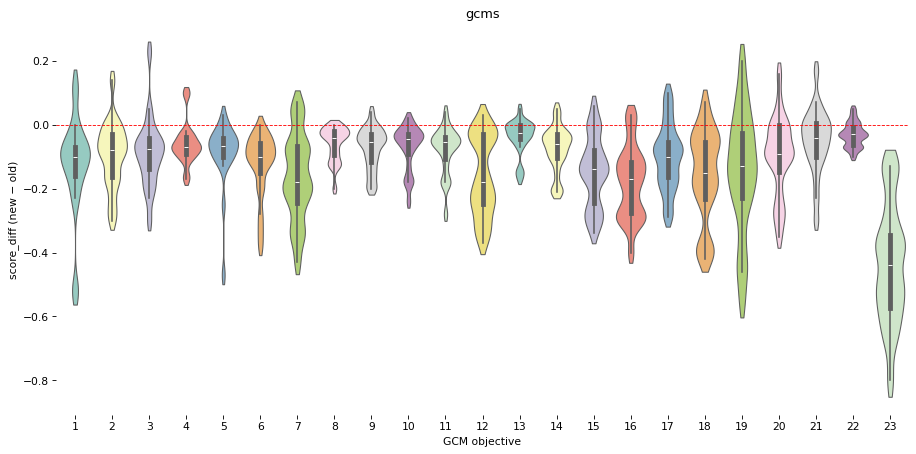

In [ ]:
plot_score_diffs(dfs, 'gcms', 'GCM objective', figsize=(12, 6), dpi=77)

### SRF Enablers

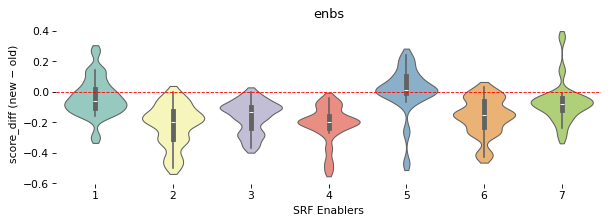

In [ ]:
plot_score_diffs(dfs, 'enbs', 'SRF Enablers', figsize=(8, 3), dpi=77)

### SRF Cross-Cutting Priorities

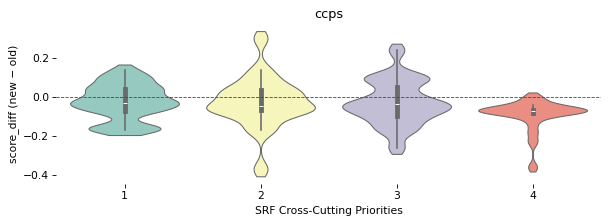

In [ ]:
plot_score_diffs(dfs, 'ccps', 'SRF Cross-Cutting Priorities', figsize=(8, 3), dpi=77)

## Rank changes overview

Among all themes where previous relevance score was `> 0.83` (**FUNDAMENTAL**), what percentage of them have undergone a change in rank (`rank_diff != 0`)

In [ ]:
dfs[dfs.score_old > 0.83].groupby('mapping_type').apply(lambda x: 100 * (x.rank_diff != 0).sum() / len(x)).round(1).sort_values()

mapping_type
ccps    16.7
gcms    34.3
outs    40.7
enbs    44.4
dtype: float64

## Tentative Intepretation

Here's a tentative interpretation linking the observed changes to the prompt updates:

**General downward shift in scores (GCMs and partly CCPs/Enablers)**
The broad negative drift across most GCM objectives likely reflects the combined effect of **more rigorous section selection** (#7) and **explicit excerpt-based hedging** (#5). With fewer but better-curated sections, the model has less text to draw relevance from, naturally producing more conservative scores.

**GCM 23 - dramatic outlier**
The extreme downward shift for GCM 23 (median around −0.4 to −0.6, with tails reaching −0.8) is the clearest signal in the whole analysis, and directly traces to the **GCM 23 downgrading rule** (#1). This change is working as intended.

**SRF Enablers — highest rank instability (44.4%)**
The **enablers reframing** (#2) — distinguishing institutional capacity from programmatic tools — appears to have significantly reshuffled rankings among top-scoring enablers, even when scores themselves didn't move dramatically. This is the mapping type most affected by rank changes among "Fundamental" tags, suggesting the semantic reframing hit harder than the numeric shift alone.

**GCM descriptions added (#6)**
The richer per-objective context may have sharpened discrimination between objectives, reducing spurious tagging and contributing to the general score compression downward.

**CCPs — relatively stable ranks (16.7%)**
Cross-cutting priorities appear least disrupted overall, which is consistent with the fact that none of the 7 updates specifically targeted CCP scoring logic.

**Caveat**: This is based on 20 reports only — patterns, especially for less-tagged objectives, should be interpreted with caution until the full dataset is processed.


## Per evaluation report

**REMINDER**, our "RELEVANCE SCORE FRAMEWORK" is as follows:
- score >= 0.84: **FUNDAMENTAL**
- 0.66 <= score < 0.83: **RELEVANT**
- 0.34 <= score < 0.66: **PERIPHERAL**
- score < 0.34: **NOT RELEVANT**